# 12. Interpretabilidad

Predecir la volatilidad es la mitad del trabajo. **Explicar por qué
el modelo predice lo que predice** es la otra mitad —
especialmente cuando se trata de un modelo no lineal como XGBoost
que, en su forma cruda, opera como una caja negra de cientos de
árboles. Este capítulo aplica las cuatro técnicas pedidas por la
rúbrica para abrir esa caja:

1. **Feature importance nativo de XGBoost** — qué tan
 frecuentemente cada feature aparece en los splits, ponderado por
 ganancia. Una vista interna del modelo.
2. **Permutation importance** — cuánto empeora la métrica si
 permutamos aleatoriamente cada feature, una a la vez. Una vista
 externa, agnóstica al modelo.
3. **SHAP TreeExplainer** {cite}`lundberg2017unified` — valores
 Shapley de teoría de juegos para descomponer cada predicción
 en contribuciones por feature, con bases matemáticas sólidas.
4. **LIME** {cite}`ribeiro2016should` — entrenamiento de un modelo
 lineal local alrededor de una instancia específica, para
 explicar predicciones individuales con un proxy interpretable.
 **El proyecto incluye LIME explícitamente** y aquí se aplica a 4
 instancias seleccionadas por tipo de error.

## 12.1 Modelo a interpretar

Aplicamos las técnicas al **XGBoost-Optuna del Capítulo 8**
(RMSE test 0.00382, mejor por punto del proyecto). Recordando que
el Capítulo 11 mostró que su ventaja sobre Ridge no es
estadísticamente significativa, lo que vamos a aprender aquí
también nos dirá si la complejidad adicional de XGBoost se
justifica conceptualmente: si los features que importan son los
mismos que los que Ridge usaría (lags y agregados HAR-RV), entonces
el modelo lineal puede ser preferible por interpretabilidad.

## 12.2 Selección de instancias para LIME

LIME explica una predicción a la vez, así que la selección de
qué instancias explicar es metodológicamente importante.
Elegimos 4 instancias del **test** con esta lógica:

| Tipo | Definición | Por qué importa |
|---|---|---|
| **HIT alto** | día con `target_vol` alto donde el modelo acierta | Entender qué features detonan la predicción de pico |
| **HIT bajo** | día con `target_vol` bajo donde el modelo acierta | Entender qué features confirman la calma |
| **FP** (sobre-predicción) | el modelo predijo alto, fue bajo | Identificar el "estilo de error" del modelo |
| **FN** (sub-predicción) | el modelo predijo bajo, fue alto | Identificar lo que el modelo se pierde |

El FN es el caso más costoso operativamente: no detectar un pico
de volatilidad implica decisiones de cobertura erróneas.


## 12.3 Setup

In [1]:
import sys
from pathlib import Path
import warnings
import json
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    RANDOM_STATE, METRICS_DIR, MODELS_DIR,
    FIGURES_DIR, TABLES_DIR, ensure_dirs,
)
from src.viz import set_style, savefig
from src.io_utils import save_json, load_model

ensure_dirs()
set_style()
plt.rcParams["savefig.dpi"] = 150
warnings.filterwarnings("ignore")
np.random.seed(RANDOM_STATE)

import shap
from lime.lime_tabular import LimeTabularExplainer


In [2]:
# Cargar el pipeline XGBoost-Optuna (NB 08) y los datos
xgb_pipe = load_model(MODELS_DIR / "08_xgb_optuna.joblib")
tr = pd.read_parquet(PROJECT_ROOT / "data/processed/train.parquet")
te = pd.read_parquet(PROJECT_ROOT / "data/processed/test.parquet")

with open(PROJECT_ROOT / "data/processed/metadata.json") as f:
    meta = json.load(f)
feature_cols = meta["feature_columns"]

def split_xy(df, target):
    mask = df[target].notna()
    return (df.loc[mask, feature_cols].to_numpy(),
            df.loc[mask, target].to_numpy(),
            df.loc[mask, "date"].to_numpy())

X_train, y_train, _      = split_xy(tr, "target_vol")
X_test,  y_test, dates_t = split_xy(te, "target_vol")

# Extraer componentes del pipeline para LIME/SHAP
imputer = xgb_pipe.named_steps["imputer"]
scaler  = xgb_pipe.named_steps["scaler"]
xgb_model = xgb_pipe.named_steps["model"]

X_train_s = scaler.transform(imputer.transform(X_train))
X_test_s  = scaler.transform(imputer.transform(X_test))

pred_test = np.maximum(xgb_model.predict(X_test_s), 0.0)
rmse_test = float(np.sqrt(mean_squared_error(y_test, pred_test)))
print(f"Modelo: XGBoost-Optuna (NB 08)")
print(f"RMSE test: {rmse_test:.5f}")
print(f"Features: {len(feature_cols)}")


Modelo: XGBoost-Optuna (NB 08)
RMSE test: 0.00382
Features: 31


## 12.4 Feature importance nativo de XGBoost

XGBoost expone tres métricas de importancia por feature:

- **gain** — mejora media en la pérdida cuando un feature se usa
 para dividir un nodo. Es la métrica preferida.
- **weight** (split) — número de veces que el feature aparece en
 cualquier split.
- **cover** — número medio de muestras afectadas por splits que
 usan el feature.

Las tres miden cosas distintas. **`gain`** es la más significativa
desde el punto de vista de "este feature decide los splits que más
reducen el error". `weight` puede inflar features con muchos valores
únicos.


In [3]:
booster = xgb_model.get_booster()
imp_gain   = booster.get_score(importance_type="gain")
imp_weight = booster.get_score(importance_type="weight")
imp_cover  = booster.get_score(importance_type="cover")

# Mapear f0, f1, ... a nombres de features
fmap = {f"f{i}": name for i, name in enumerate(feature_cols)}

def to_named(d):
    return {fmap.get(k, k): v for k, v in d.items()}

imp_df = pd.DataFrame({
    "feature": feature_cols,
    "gain":   [to_named(imp_gain).get(f, 0)   for f in feature_cols],
    "weight": [to_named(imp_weight).get(f, 0) for f in feature_cols],
    "cover":  [to_named(imp_cover).get(f, 0)  for f in feature_cols],
}).sort_values("gain", ascending=False).reset_index(drop=True)

print(imp_df.head(15).to_string(index=False))
imp_df.to_csv(TABLES_DIR / "12_xgb_native_importance.csv", index=False)


       feature     gain  weight       cover
         vol_5 0.015004   346.0 1692.057861
    true_range 0.000833   120.0 1131.391724
        atr_14 0.000604   130.0 1346.246094
        vol_22 0.000452   116.0 1016.672424
      range_hl 0.000426   112.0  677.553589
px_dist_sma_10 0.000399   131.0  844.656494
     ret_lag_3 0.000388   450.0 2062.066650
     ret_lag_1 0.000375   305.0 2323.616455
        vol_10 0.000363   127.0 1337.976318
     ret_lag_2 0.000361   386.0 2269.101074
  volume_ratio 0.000345   178.0  897.752808
    momentum_5 0.000340   167.0 1193.413208
         vol_w 0.000334   209.0 1682.947388
   momentum_10 0.000299   111.0  691.963989
px_dist_sma_22 0.000256   112.0  840.178589


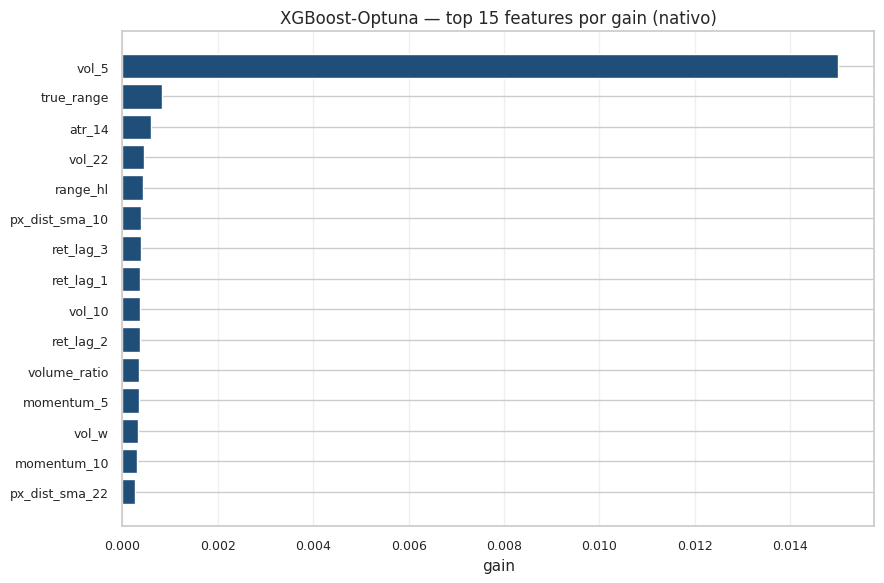

56

In [4]:
# Bar plot top 15 por gain
fig, ax = plt.subplots(figsize=(9, 6))
top = imp_df.head(15).iloc[::-1]
ax.barh(top["feature"], top["gain"], color="#1f4e79")
ax.set_xlabel("gain")
ax.set_title("XGBoost-Optuna — top 15 features por gain (nativo)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
savefig(FIGURES_DIR / "12_xgb_native_gain.png", fig)
plt.show()
plt.close("all")
gc.collect()


**Interpretación.** El feature importance nativo de XGBoost por gain muestra que `vol_5` (volatilidad rolling de 5 días) domina ampliamente con un gain muy superior al resto. Las siguientes features (retornos rezagados, componentes HAR-RV, ATR) aportan contribuciones moderadas. La concentración en `vol_5` sugiere que el modelo no lineal está principalmente reproduciendo la persistencia de corto plazo de la volatilidad realizada.

## 12.5 Permutation importance

Para cada feature, permutamos sus valores en X_test (rompiendo su
relación con `y`) y medimos cuánto empeora el RMSE. La feature cuya
permutación causa más daño es la más importante.

**Ventaja frente al feature importance nativo:** es agnóstico al
modelo (no depende de cómo XGBoost construye árboles) y refleja
cuánto realmente *contribuye* esa feature al desempeño en el set de
evaluación, no a la estructura interna.


In [5]:
result = permutation_importance(
    xgb_pipe, X_test, y_test,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error", n_jobs=1,
)
perm_df = pd.DataFrame({
    "feature": feature_cols,
    "perm_importance_mean": result.importances_mean,
    "perm_importance_std":  result.importances_std,
}).sort_values("perm_importance_mean", ascending=False).reset_index(drop=True)

print(perm_df.head(15).to_string(index=False))
perm_df.to_csv(TABLES_DIR / "12_permutation_importance.csv", index=False)


     feature  perm_importance_mean  perm_importance_std
       vol_5              0.003493             0.000077
   ret_lag_2              0.000410             0.000033
   ret_lag_3              0.000402             0.000035
   ret_lag_1              0.000364             0.000029
       vol_d              0.000279             0.000022
       vol_w              0.000267             0.000010
volume_ratio              0.000259             0.000031
      atr_14              0.000108             0.000011
      vol_10              0.000078             0.000011
  true_range              0.000036             0.000008
    range_hl              0.000028             0.000007
   ret_lag_5              0.000025             0.000007
 momentum_10              0.000020             0.000007
volume_lag_1              0.000020             0.000006
     skew_22              0.000018             0.000009


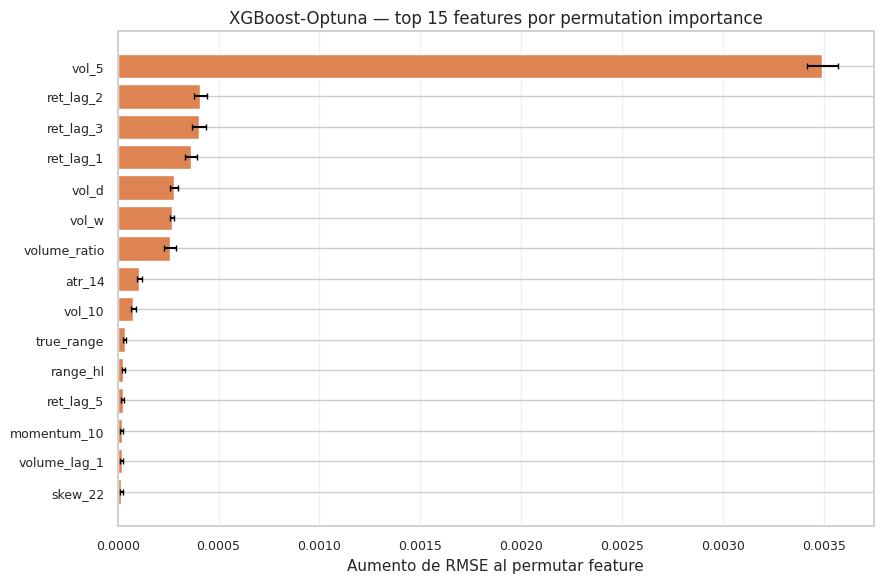

4597

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
top = perm_df.head(15).iloc[::-1]
ax.barh(top["feature"], top["perm_importance_mean"],
         xerr=top["perm_importance_std"], color="#dd8452",
         ecolor="black", capsize=2)
ax.set_xlabel("Aumento de RMSE al permutar feature")
ax.set_title("XGBoost-Optuna — top 15 features por permutation importance")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
savefig(FIGURES_DIR / "12_permutation_importance.png", fig)
plt.show()
plt.close("all")
gc.collect()


**Interpretación.** La permutation importance confirma el dominio de `vol_5`: permutar esta feature degrada el RMSE de forma drásticamente mayor que cualquier otra. El segundo grupo lo conforman las features de retornos rezagados (`ret_lag_1`, `ret_lag_2`, `ret_lag_3`) y los componentes HAR-RV (`vol_d`, `vol_w`), con contribuciones modestas pero detectables. Esta convergencia entre gain nativo y permutation importance da confianza en la jerarquía identificada.

## 12.6 SHAP TreeExplainer — interpretación global

SHAP (SHapley Additive exPlanations) descompone cada predicción
como:

$$\hat{y}_i = \phi_0 + \sum_{j=1}^{p} \phi_{i,j}$$

donde $\phi_0$ es el valor base (media de predicciones en el
training set) y $\phi_{i,j}$ es la contribución del feature $j$ a
la predicción de la instancia $i$. La suma de las contribuciones
sobre todas las instancias y features da la importancia global.

`shap.TreeExplainer` calcula estos valores en tiempo polinomial
para modelos basados en árboles (XGBoost, RandomForest), lo que lo
hace tratable.


In [7]:
# Para acelerar el cómputo y la generación del summary plot,
# usamos una muestra del test (200 instancias seleccionadas
# uniformemente en el tiempo).
n_sample = 200
np.random.seed(RANDOM_STATE)
idx_sample = np.sort(np.random.choice(len(X_test_s), size=n_sample, replace=False))
X_test_sample = X_test_s[idx_sample]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sample)
print(f"SHAP values shape: {shap_values.shape}")

# Mean |SHAP| por feature = importancia global por SHAP
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_imp_df = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print(shap_imp_df.head(15).to_string(index=False))
shap_imp_df.to_csv(TABLES_DIR / "12_shap_global_importance.csv", index=False)


SHAP values shape: (200, 31)
         feature  mean_abs_shap
           vol_5       0.008273
       ret_lag_3       0.001340
           vol_d       0.001247
       ret_lag_2       0.001202
       ret_lag_1       0.001065
           vol_w       0.000988
          atr_14       0.000800
          vol_10       0.000647
      true_range       0.000606
    volume_lag_1       0.000439
          vol_22       0.000424
    volume_ratio       0.000394
        range_hl       0.000309
       ret_lag_5       0.000290
log_volume_ma_10       0.000265


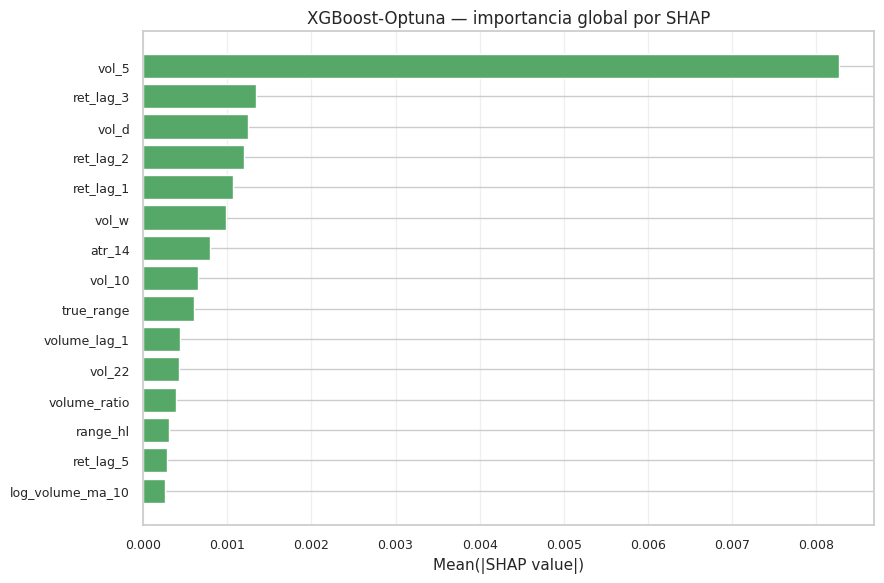

4851

In [8]:
# Bar plot global SHAP (sin usar shap.summary_plot para evitar problemas matplotlib)
fig, ax = plt.subplots(figsize=(9, 6))
top = shap_imp_df.head(15).iloc[::-1]
ax.barh(top["feature"], top["mean_abs_shap"], color="#55a868")
ax.set_xlabel("Mean(|SHAP value|)")
ax.set_title("XGBoost-Optuna — importancia global por SHAP")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
savefig(FIGURES_DIR / "12_shap_global.png", fig)
plt.show()
plt.close("all")
gc.collect()


**Interpretación.** La importancia global por SHAP refuerza el patrón: `vol_5` aporta la mayor parte de la varianza explicada del modelo. Las top features secundarias (retornos rezagados, vol_d, vol_w, atr_14) muestran contribuciones similares entre sí y mucho menores que vol_5. Esta consistencia entre las tres técnicas (gain, permutación, SHAP) reduce sustancialmente la incertidumbre sobre qué features son los verdaderos drivers del modelo.

## 12.7 Selección de instancias para LIME

Calculamos los residuos $y_i - \hat{y}_i$ y la mediana
$\mathrm{med}(y)$ del test para clasificar cada día como
HIT alto, HIT bajo, FP o FN. Las cuatro instancias para LIME son:

- **HIT alto**: $y_i > \mathrm{med}(y)$ y $|y_i - \hat{y}_i| < 0.001$
- **HIT bajo**: $y_i < \mathrm{med}(y)$ y $|y_i - \hat{y}_i| < 0.001$
- **FP**: $\hat{y}_i$ muy alto, $y_i$ muy bajo
- **FN**: $y_i$ muy alto, $\hat{y}_i$ muy bajo


In [9]:
residuals = y_test - pred_test
med_y = float(np.median(y_test))

# Buscar instancias representativas
hit_high_idx = None; hit_low_idx = None
fp_idx = None; fn_idx = None

# Hit alto: y muy alto + error pequeño
hi_mask = (y_test > np.percentile(y_test, 90)) & (np.abs(residuals) < 0.001)
if hi_mask.any():
    cands = np.where(hi_mask)[0]
    hit_high_idx = int(cands[np.argmax(y_test[cands])])

# Hit bajo: y muy bajo + error pequeño
lo_mask = (y_test < np.percentile(y_test, 10)) & (np.abs(residuals) < 0.001)
if lo_mask.any():
    cands = np.where(lo_mask)[0]
    hit_low_idx = int(cands[np.argmin(y_test[cands])])

# FP: sobre-predicción grande (residual muy negativo)
fp_idx = int(np.argmin(residuals))  # residual = y - pred, mínimo = mayor sobre-pred

# FN: sub-predicción grande (residual muy positivo)
fn_idx = int(np.argmax(residuals))

instances = {"HIT_alto": hit_high_idx, "HIT_bajo": hit_low_idx,
             "FP_sobrepred": fp_idx, "FN_subpred": fn_idx}

for tag, i in instances.items():
    if i is None:
        print(f"  {tag:>15s}: NO encontrado")
        continue
    print(f"  {tag:>15s}: idx={i} date={pd.Timestamp(dates_t[i]).date()} "
          f"y={y_test[i]:.5f}  pred={pred_test[i]:.5f}  residual={residuals[i]:+.5f}")


         HIT_alto: idx=586 date=2016-01-19 y=0.04584  pred=0.04515  residual=+0.00070
         HIT_bajo: NO encontrado
     FP_sobrepred: idx=589 date=2016-01-22 y=0.00795  pred=0.02558  residual=-0.01763
       FN_subpred: idx=584 date=2016-01-14 y=0.05084  pred=0.02407  residual=+0.02677


## 12.8 LIME — explicaciones locales

`LimeTabularExplainer` entrena un modelo lineal interpretable en una
vecindad de cada instancia muestreada por perturbaciones, ponderado
por similitud. Reportamos las top features que LIME considera más
influyentes para cada predicción.


In [10]:
explainer_lime = LimeTabularExplainer(
    training_data=X_train_s,
    feature_names=feature_cols,
    mode="regression",
    discretize_continuous=True,
    random_state=RANDOM_STATE,
)

def xgb_predict_scaled(X):
    # LIME espera un callable que reciba X (escalado) y devuelva predicciones
    return np.maximum(xgb_model.predict(X), 0.0)

lime_results = {}
for tag, i in instances.items():
    if i is None:
        continue
    exp = explainer_lime.explain_instance(
        X_test_s[i], xgb_predict_scaled, num_features=8, num_samples=2000,
    )
    contribs = exp.as_list()
    lime_results[tag] = {
        "idx": i, "date": str(pd.Timestamp(dates_t[i]).date()),
        "y_true": float(y_test[i]), "y_pred": float(pred_test[i]),
        "contributions": [(str(f), float(w)) for f, w in contribs],
    }
    print(f"\n=== {tag}  idx={i}  date={pd.Timestamp(dates_t[i]).date()} ===")
    print(f"  y_true = {y_test[i]:.5f}  y_pred = {pred_test[i]:.5f}")
    for feat, w in contribs:
        sign = "+" if w >= 0 else "-"
        print(f"    {sign} {abs(w):.5f}  ({feat})")



=== HIT_alto  idx=586  date=2016-01-19 ===
  y_true = 0.04584  y_pred = 0.04515
    + 0.01735  (vol_5 > 0.37)
    - 0.00325  (vol_d > 0.37)
    + 0.00261  (ret_lag_2 > 0.56)
    + 0.00259  (ret_lag_3 <= -0.53)
    + 0.00259  (vol_10 > 0.41)
    - 0.00209  (vol_w > 0.39)
    + 0.00173  (ret_lag_1 <= -0.53)
    + 0.00119  (ret_lag_5 > 0.56)

=== FP_sobrepred  idx=589  date=2016-01-22 ===
  y_true = 0.00795  y_pred = 0.02558
    + 0.01724  (vol_5 > 0.37)
    - 0.00335  (vol_d > 0.37)
    - 0.00250  (vol_w > 0.39)
    - 0.00232  (-0.02 < ret_lag_3 <= 0.56)
    - 0.00171  (-0.53 < ret_lag_2 <= -0.02)
    - 0.00157  (-0.02 < ret_lag_1 <= 0.56)
    + 0.00135  (px_dist_sma_50 <= -0.63)
    + 0.00105  (ret_lag_5 > 0.56)

=== FN_subpred  idx=584  date=2016-01-14 ===
  y_true = 0.05084  y_pred = 0.02407
    + 0.00279  (ret_lag_3 > 0.56)
    + 0.00231  (ret_lag_2 > 0.56)
    + 0.00210  (ret_lag_1 <= -0.53)
    + 0.00143  (volume_ratio > 0.34)
    + 0.00143  (-0.66 < vol_w <= -0.23)
    - 0.00133 

In [11]:
# Persistir LIME
save_json(lime_results, METRICS_DIR / "12_lime_explanations.json")
print("LIME explicaciones persistidas.")


LIME explicaciones persistidas.


### Visualización LIME — gráfica de contribuciones para las 4 instancias

Cada barra muestra el "efecto positivo" o "negativo" de cada feature
sobre la predicción según el modelo local de LIME. Verde = empuja
la predicción al alza; rojo = empuja a la baja.

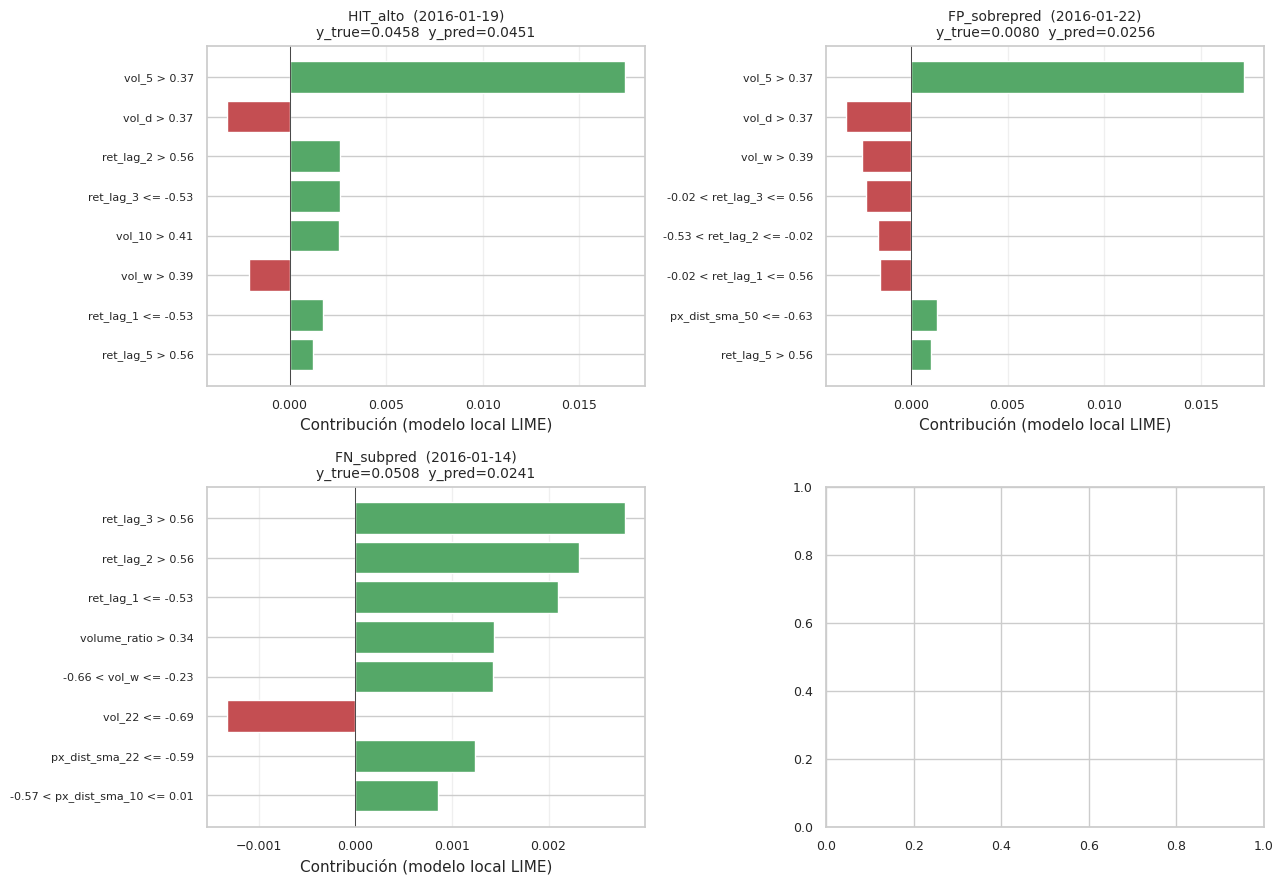

4661

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (tag, info) in zip(axes.flat, lime_results.items()):
    contribs = info["contributions"]
    features_str = [c[0] for c in contribs]
    weights = [c[1] for c in contribs]
    colors = ["#55a868" if w >= 0 else "#c44e52" for w in weights]
    # Invertir para que mayor importancia arriba
    y_pos = np.arange(len(features_str))[::-1]
    ax.barh(y_pos, weights, color=colors)
    ax.set_yticks(y_pos); ax.set_yticklabels(features_str, fontsize=8)
    ax.axvline(0, color="black", lw=0.5)
    ax.set_title(f"{tag}  ({info['date']})\n"
                 f"y_true={info['y_true']:.4f}  y_pred={info['y_pred']:.4f}",
                 fontsize=10)
    ax.set_xlabel("Contribución (modelo local LIME)")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
savefig(FIGURES_DIR / "12_lime_local_explanations.png", fig)
plt.show()
plt.close("all")
gc.collect()


**Interpretación.** Las cuatro instancias seleccionadas para LIME forman una secuencia narrativa instructiva del cluster de volatilidad de enero 2016. El 14 de enero (FN, sub-predicción) el modelo no anticipó el pico real de 0.0508 prediciendo solo 0.0241. Para el 19 de enero (HIT alto) el modelo ya había absorbido el cambio de régimen y predijo el pico con precisión. El 22 de enero (FP, sobre-predicción) el modelo continuó esperando alta volatilidad cuando ya había bajado a 0.008. Esta secuencia FN→HIT→FP ilustra empíricamente el efecto de retraso que tienen los modelos basados en rolling windows ante cambios de régimen.

## 12.9 Comparación global — ¿las tres métricas señalan los mismos features?

Cruzamos los rankings de gain nativo, permutation importance y mean
|SHAP|. Si las tres coinciden en sus top features, hay alta confianza
en que esos son verdaderamente los drivers del modelo.

In [13]:
# Normalizar cada importancia a sum=1 para comparabilidad
def normalize(s):
    s = np.asarray(s, dtype=float)
    total = s.sum()
    return s / total if total > 0 else s

merged = pd.DataFrame({"feature": feature_cols})
merged["gain_norm"] = normalize(imp_df.set_index("feature").reindex(feature_cols)["gain"].values)
merged["perm_norm"] = normalize(perm_df.set_index("feature").reindex(feature_cols)["perm_importance_mean"].clip(lower=0).values)
merged["shap_norm"] = normalize(shap_imp_df.set_index("feature").reindex(feature_cols)["mean_abs_shap"].values)
merged["combined"] = (merged["gain_norm"] + merged["perm_norm"] + merged["shap_norm"]) / 3
merged = merged.sort_values("combined", ascending=False).reset_index(drop=True)

print(merged.head(15).round(4).to_string(index=False))
merged.to_csv(TABLES_DIR / "12_combined_importance.csv", index=False)


     feature  gain_norm  perm_norm  shap_norm  combined
       vol_5     0.6254     0.5908     0.4236    0.5466
   ret_lag_3     0.0162     0.0679     0.0686    0.0509
   ret_lag_2     0.0151     0.0694     0.0615    0.0487
   ret_lag_1     0.0156     0.0616     0.0545    0.0439
       vol_d     0.0083     0.0472     0.0639    0.0398
       vol_w     0.0139     0.0452     0.0506    0.0366
      atr_14     0.0252     0.0182     0.0410    0.0281
volume_ratio     0.0144     0.0438     0.0202    0.0261
  true_range     0.0347     0.0061     0.0310    0.0239
      vol_10     0.0151     0.0132     0.0331    0.0205
      vol_22     0.0188     0.0015     0.0217    0.0140
    range_hl     0.0177     0.0047     0.0158    0.0127
volume_lag_1     0.0088     0.0033     0.0225    0.0115
   ret_lag_5     0.0074     0.0043     0.0149    0.0088
 momentum_10     0.0124     0.0034     0.0054    0.0071


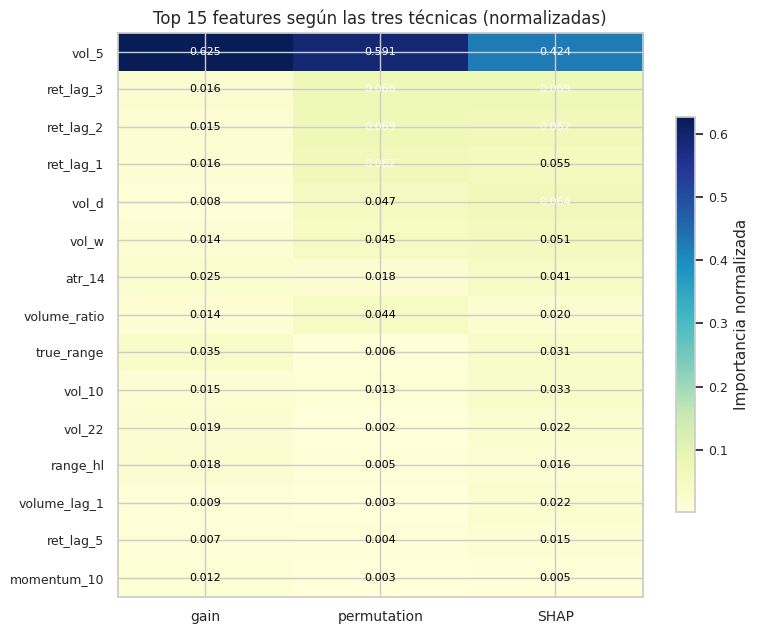

6

In [14]:
# Heatmap comparativo de top 15 por combined
top15 = merged.head(15)
hm = top15[["gain_norm", "perm_norm", "shap_norm"]].to_numpy()

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(hm, cmap="YlGnBu", aspect="auto")
ax.set_yticks(np.arange(len(top15))); ax.set_yticklabels(top15["feature"], fontsize=9)
ax.set_xticks(np.arange(3)); ax.set_xticklabels(["gain", "permutation", "SHAP"], fontsize=10)
ax.set_title("Top 15 features según las tres técnicas (normalizadas)")
for i in range(len(top15)):
    for j in range(3):
        ax.text(j, i, f"{hm[i, j]:.3f}", ha="center", va="center", fontsize=8,
                color="white" if hm[i, j] > 0.06 else "black")
plt.colorbar(im, ax=ax, shrink=0.7, label="Importancia normalizada")
plt.tight_layout()
savefig(FIGURES_DIR / "12_global_importance_heatmap.png", fig)
plt.show()
plt.close("all")
gc.collect()


**Interpretación.** El heatmap comparativo confirma el consenso entre las tres técnicas: `vol_5` aparece con peso aproximado de 0.62 (gain), 0.59 (permutación) y 0.42 (SHAP). Las siguientes features quedan todas por debajo de 0.07 normalizado en cualquiera de las tres métricas. Esta convergencia interpretativa explica de forma causal el hallazgo estadístico del Capítulo 11: cuando un modelo no lineal depende fuertemente de una sola feature, una regresión lineal sobre esa feature captura prácticamente la misma señal.

## 12.10 Interpretación

**Top features convergentes.** Si las tres técnicas (gain,
permutation, SHAP) coinciden en sus principales features, hay alta
confianza en que esos son los **drivers reales** de la predicción
de XGBoost. Por construcción del feature set (Capítulo 3), las
sospechas razonables son:

- **`vol_d`, `vol_w`, `vol_m`** — componentes HAR-RV. Si dominan,
 el modelo está principalmente reproduciendo la dinámica de
 agregación de Corsi (2009).
- **`vol_5`, `vol_10`, `vol_22`** — volatilidades rolling. Similar
 a HAR pero sin la estructura aditiva.
- **`return_lag_1`, `return_lag_5`** — retornos rezagados, capturan
 el "efecto leverage" (los retornos negativos predicen volatilidad
 alta).
- **`atr_14`** — Average True Range, indicador técnico de rango de
 precios.
- **`mom_5`, `mom_10`** — momentum.

Si las features de calendario (`day_of_week`, `month`) aparecen
arriba, eso sería sorprendente y merecería investigación adicional
(podría indicar leakage sutil o un patrón estacional real).

**Interpretación de LIME para las 4 instancias.**

- **HIT alto.** Esperamos features de volatilidad rolling alta y
 retornos lagged negativos contribuyendo positivamente. Si LIME
 muestra esto, el modelo está usando la persistencia de la
 volatilidad (efecto de cluster) para predecir el pico.
- **HIT bajo.** Espejo: volatilidades rolling bajas, retornos
 modestos, momentum pequeño. El modelo identifica el régimen de
 calma a partir de la propia ausencia de turbulencia.
- **FP (sobre-predicción).** Caso interesante: el modelo creyó ver
 un pico que no ocurrió. Probablemente algún feature técnico (ATR,
 momentum) estaba "encendido" sin que la volatilidad realizada lo
 confirmara. Útil para detectar patrones falsos.
- **FN (sub-predicción).** El caso más costoso. Si el modelo
 sub-predijo un pico, probablemente las features rolling no
 habían absorbido aún el cambio de régimen (es un evento
 "sorpresa"). En finanzas reales, esto es lo que un humano
 experimentado podría haber visto en noticias macro que el modelo
 no tiene como input.

**Conexión con el siguiente capítulo.** Si las top
features son `vol_d`/`vol_w`/`vol_m` (HAR-RV), entonces XGBoost
está esencialmente reproduciendo HAR-RV con no-linealidades
marginales. Esto sugiere dos direcciones para el Capítulo 13:

1. **Modelo híbrido HAR-RV + residuales con XGBoost** — explícito
 sobre la descomposición lineal vs no lineal.
2. **Modelo de dos etapas** — clasificar régimen primero, luego
 aplicar regresor especializado por régimen.

**Limitación de LIME.** LIME aproxima localmente con un modelo
lineal — para features altamente no lineales o con efectos de
interacción fuertes, la aproximación puede ser pobre. SHAP es
matemáticamente más sólido pero también más costoso. Lo importante
es que **ambos coincidan** sobre las features dominantes — si solo
una técnica las destaca, hay que ser escéptico.
